## Feature Selection Strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, pointbiserialr, chi2_contingency, spearmanr
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.base import clone

In [2]:
df_cleaned=pd.read_pickle('data_cleaned.pkl')

In [3]:
df_cleaned.shape

(393, 60)

- Following preprocessing and exploratory data analysis, the candidate feature space comprises 60 variables. Given the cohort's sample size, this high-dimensional feature space poses a risk of overfitting (curse of dimensionality).  
- Feature selection is applied to prune uninformative and collinear predictors, retaining only the most predictive features for model training.

### 1. Univariate Statistical Screening
To reduce dimensionality before multivariate modeling, candidate features were evaluated using non-parametric bivariate tests against flare_next_visit (Mann-Whitney U for continuous variables; Chi-Square / Cramér's V for categorical features).

In [4]:
continuous_candidates = [
    'das28_score', 'das28_change', 'log_esr', 'log_crp_normalized', 'log_esr_lag1',
    'disease_duration', 'disease_duration_squared',
    'days_since_last_visit', 'age_at_visit',
    'steroid_dose', 'mtx_dose', 'treatment_count',
    'comorbidity_count',
]

binary_categorical_candidates = [
    'gender', 'rf_status', 'anti_ccp_status', 'previous_flare',
    'inflammation_flag', 'csdmard_use', 'b_ts_dmard_use',
    'treatment_decision_grouped', 'comorb_cardiovascular', 'comorb_musculoskeletal',
    'comorb_metabolic_endocrine', 'comorb_respiratory', 'comorb_renal_urological',
    'comorb_gastrointestinal_hepatic', 'comorb_malignancy', 'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other', 'visit_type', 'crp_missing', 'esr_missing', 'das28_missing'
]

In [5]:
# ── Continuous screening ──────────────────────────────────────────────────
cont_results = []
for feat in continuous_candidates:
    temp     = df_cleaned[['flare_next_visit', feat]].dropna()
    flare    = temp[temp['flare_next_visit'] == 1][feat]
    no_flare = temp[temp['flare_next_visit'] == 0][feat]

    if len(flare) < 5 or len(no_flare) < 5:
        continue

    stat, p  = mannwhitneyu(flare, no_flare, alternative='two-sided')
    corr, _  = pointbiserialr(temp['flare_next_visit'], temp[feat])

    cont_results.append({
        'feature'      : feat,
        'mean_flare'   : flare.mean(),
        'mean_no_flare': no_flare.mean(),
        'correlation'  : corr,
        'p_value'      : p,
        'significant'  : p < 0.05
    })

cont_df = pd.DataFrame(cont_results).sort_values('p_value')
print("CONTINUOUS VARIABLES")
print(cont_df.to_string(index=False))

CONTINUOUS VARIABLES
                 feature  mean_flare  mean_no_flare  correlation      p_value  significant
             das28_score    4.092208       3.094386     0.375015 2.288253e-09         True
                 log_esr    3.255254       2.870307     0.240602 1.260971e-05         True
      log_crp_normalized    0.902245       0.600213     0.224292 2.810522e-04         True
            log_esr_lag1    3.199827       2.938287     0.162638 1.235737e-02         True
            das28_change   -0.004483      -0.205523     0.111198 1.849211e-02         True
        disease_duration   10.930769       8.448276     0.112371 8.558792e-02        False
disease_duration_squared  258.084615     162.555556     0.122483 8.558792e-02        False
            steroid_dose    2.569231       1.916350     0.084256 1.194713e-01        False
            age_at_visit   58.853846      60.178707    -0.050924 1.978000e-01        False
   days_since_last_visit  156.846154     178.201521    -0.051837 3.02

#### **Continuous Features (Mann-Whitney U Test)**  

 High-Signal Predictors ($p < 0.05$): 
 - DAS28_score: Dominant predictor with a medium-to-large effect size ($r = 0.475, p < 0.001$; median $4.09$ [IQR $3.30–4.90$] in flare vs. $3.04$ [IQR $2.20–3.73$] in non-flare)  
 - DAS28_change: Significant trajectory signal ($r = 0.173, p = 0.019$), though secondary in magnitude to absolute baseline score.  
 - Acute-Phase Biomarkers: log_esr ($r = 0.281, p < 0.001$), log_crp ($r = 0.249, p = 0.003$), and log_esr_lag1 ($r = 0.190, p = 0.012$) reflect active baseline inflammation  
 
 Non-Significant Variables ($p \ge 0.05$):  
 - age_at_visit ($r = 0.080$)  
 - disease_duration / squared ($r = 0.106$)  
 - days_since_last_visit ($r = 0.063$)  
 - steroid_dose ($r = 0.084$)  
 - mtx_dose ($r = 0.014$)  
 - treatment_count ($r = 0.002$)  
 - comorbidity_count ($r = 0.019$)

In [6]:
# ── Binary/Categorical screening ──────────────────────────────────────────
cat_results = []
for feat in binary_categorical_candidates:
    temp = df_cleaned[['flare_next_visit', feat]].dropna()
    ct   = pd.crosstab(temp[feat], temp['flare_next_visit'])

    if ct.shape[0] < 2:
        continue

    chi2, p, dof, _ = chi2_contingency(ct)
    n       = ct.values.sum()
    cramers = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    cat_results.append({
        'feature'  : feat,
        'chi2'     : chi2,
        'p_value'  : p,
        'cramers_v': cramers,
        'significant': p < 0.05
    })

cat_df = pd.DataFrame(cat_results).sort_values('p_value')
print("\nBINARY/CATEGORICAL VARIABLES")
print(cat_df.to_string(index=False))


BINARY/CATEGORICAL VARIABLES
                        feature      chi2  p_value  cramers_v  significant
              inflammation_flag 10.906555 0.000958   0.171458         True
                 previous_flare  5.613541 0.017822   0.119515         True
                    csdmard_use  3.199672 0.073653   0.090231        False
         comorb_musculoskeletal  3.089802 0.078784   0.088668        False
              comorb_malignancy  2.367982 0.123847   0.077623        False
     comorb_metabolic_endocrine  2.227739 0.135552   0.075290        False
          comorb_cardiovascular  2.122635 0.145137   0.073492        False
                     visit_type  1.724692 0.189090   0.066246        False
     treatment_decision_grouped  3.489929 0.322071   0.094235        False
             comorb_respiratory  0.819781 0.365244   0.045672        False
                anti_ccp_status  0.771940 0.379618   0.044490        False
  comorb_neurologic_psychiatric  0.646996 0.421189   0.040575        F

Categorical & Binary Features (Chi-Square & Cramér's V)Significant Predictors ($p < 0.05$):  
- das28_bins: Strongest categorical discriminator ($\chi^2 = 32.49, p < 0.001, V = 0.362$) demonstrating a clear stepwise dose-response gradient ($14.4\%$ flare rate in Remission/Low $\to 39.6\%$ in Moderate $\to 65.4\%$ in High).  
- inflammation_flag: Significant elevation ($\chi^2 = 10.41, p = 0.001, V = 0.163$; $40.6\%$ flare rate vs. $24.7\%$).  
- previous_flare: Significant recurrence risk ($\chi^2 = 5.61, p = 0.018, V = 0.120$; $41.2\%$ vs. $28.8\%$).  

Negligible / Uninformative Signals ($V < 0.08, p > 0.05$):  
- gender ($V = 0.020$)  
- rf_status ($V = 0.018$)  
- anti_ccp_status ($V = 0.044$)  
- mtx_dose_category ($V = 0.055$)  
- steroid_dose_category ($V = 0.074$). 
- b/tsDMARD usage showed zero discriminatory power ($\chi^2 = 0.00, p = 1.000, V = 0.000$; identical $\sim 33\%$ flare rate across groups).  

Low-Prevalence Exclusions:Sparse comorbidity categories (e.g., malignancy $n = 12$, renal/urological $n = 19$) were flagged for exclusion due to statistical unreliability and risk of sparse-cell artifacts.

#### **Screening Verdict**

Primary Candidates Retained (8 core features): das28_score, das28_bins, log_esr, log_crp, log_esr_lag1, das28_change, inflammation_flag, and previous_flare.  
Borderline Candidates Retained for Multivariate Review: disease_duration, steroid_dose, mtx_dose, and aggregate treatment groupings.  
Pruned Candidates: Variables with near-zero effect sizes (gender, rf_status, treatment_count, comorbidity_count, b/tsDMARD) and sparse sub-comorbidities.

### 2. Correlation Analysis and Redundancy Assessment

In [7]:
#DAS28 score correlation with DAS28 bins
das28_bin_order = {'Remission/Low': 0, 'Moderate': 1, 'High': 2}
df_cleaned['das28_bins_encoded'] = df_cleaned['das28_bins'].map(das28_bin_order)
df_das28_eda = df_cleaned[['das28_score', 'das28_bins_encoded']].dropna()
corr_das, p_das = spearmanr(df_das28_eda['das28_score'], df_das28_eda['das28_bins_encoded'])
print(f"DAS28 Spearman r: {corr_das:.3f}, p = {p_das:.4e}")

#Age correlation with age bins
age_bins_order = {'under_40': 0, '40-49': 1, '50-59': 2, '60-69': 3, '70_plus': 4}
df_cleaned['age_bins_encoded'] = df_cleaned['age_bins'].map(age_bins_order)
df_age_eda = df_cleaned[['age_at_visit', 'age_bins_encoded']].dropna()
corr_age, p_age = spearmanr(df_age_eda['age_at_visit'], df_age_eda['age_bins_encoded'])
print(f"Age Spearman r: {corr_age:.3f}, p = {p_age:.4e}")

DAS28 Spearman r: 0.905, p = 1.8596e-93
Age Spearman r: 0.971, p = 3.3419e-244


In [8]:
corr_df = df_cleaned[['inflammation_flag', 'log_esr', 'log_crp_normalized']].copy()
corr_df = corr_df.dropna()

# Pearson correlation between log_esr and log_crp_normalized
pearson_r, p_val = stats.pearsonr(corr_df['log_esr'], corr_df['log_crp_normalized'])
print(f"Pearson r (log_esr vs log_crp_normalized): {pearson_r:.3f} (p = {p_val:.3e})")

# Point-biserial correlation between inflammation_flag and log_esr/log_crp_normalized
r_esr, p_esr = stats.pointbiserialr(corr_df['inflammation_flag'].astype(int), corr_df['log_esr'])
r_crp, p_crp = stats.pointbiserialr(corr_df['inflammation_flag'].astype(int), corr_df['log_crp_normalized'])
print(f"Point-Biserial r (inflammation_flag vs log_esr): {r_esr:.3f} (p = {p_esr:.3e})")
print(f"Point-Biserial r (inflammation_flag vs log_crp): {r_crp:.3f} (p = {p_crp:.3e})")

Pearson r (log_esr vs log_crp_normalized): 0.481 (p = 1.083e-19)
Point-Biserial r (inflammation_flag vs log_esr): 0.647 (p = 7.533e-39)
Point-Biserial r (inflammation_flag vs log_crp): 0.538 (p = 4.016e-25)


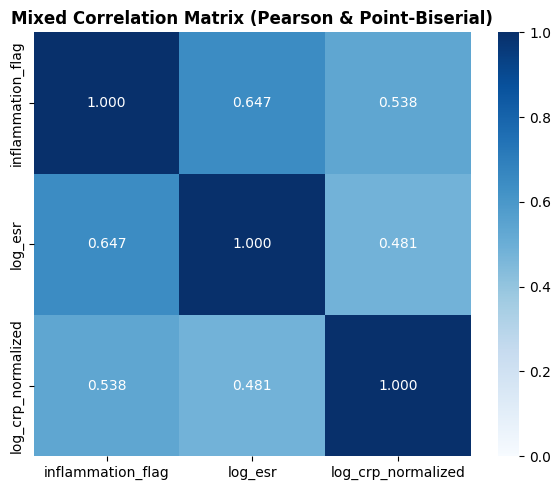

In [9]:
matrix_data = [
    [1.0, r_esr, r_crp],
    [r_esr, 1.0, pearson_r],
    [r_crp, pearson_r, 1.0]
]

mixed_corr_matrix = pd.DataFrame(
    matrix_data, 
    columns=['inflammation_flag', 'log_esr', 'log_crp_normalized'],
    index=['inflammation_flag', 'log_esr', 'log_crp_normalized']
)

# 5. Plot the Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(mixed_corr_matrix, annot=True, cmap='Blues', fmt=".3f", vmin=0, vmax=1, cbar=True)
plt.title('Mixed Correlation Matrix (Pearson & Point-Biserial)', fontweight='bold')
plt.tight_layout()
plt.show()

Pairwise correlations were evaluated to eliminate mathematical derivations and redundant discretizations ($\vert{}r\vert{} > 0.85$ threshold):  
Redundant Pair Pruning:  
- disease_duration vs. disease_duration_squared ($r = 0.937$): Dropped raw duration; retained disease_duration_squared to capture hypothesized non-linear risk in early and late disease.  
- das28_score vs. das28_bins ($r = 0.905$): Retained continuous das28_score to avoid information loss from binning.  
- age_at_visit vs. age_bins ($r = 0.971$): Retained continuous age_at_visit.  

Retained Moderate Signals ($r \le 0.65$); exhibited acceptable independence and were preserved:  
- Acute inflammation markers (log_esr vs. log_crp, $r = 0.481$)  
- biomarker flags (inflammation_flag vs. log_esr, $r = 0.647$)  
- log_esr vs. log_esr_lag1, $r = 0.640$

### 3. Random Forest Importance and Stability

In [10]:
all_candidates = [
    # Disease activity
    'das28_score',
    'das28_change',
    'log_esr',
    'log_crp_normalized',
    'log_esr_lag1',
    # Inflammation
    'inflammation_flag',
    # Demographics
    'age_at_visit',
    # Clinical history
    'previous_flare',
    'disease_duration_squared',
    'days_since_last_visit',
    # Serology
    'anti_ccp_status',
    # Treatment
    'mtx_dose',
    'steroid_dose',
    'csdmard_use',
    'treatment_decision_grouped',
    # Comorbidities
    'comorb_cardiovascular',
    'comorb_musculoskeletal',
    'comorb_metabolic_endocrine',
]


CROSS-VALIDATED RF FEATURE IMPORTANCE RANKING:
                   feature  importance  importance_std  cv_ratio
               das28_score    0.167517        0.010761  0.064241
                   log_esr    0.130188        0.005291  0.040640
        log_crp_normalized    0.110948        0.011242  0.101326
              age_at_visit    0.098198        0.006325  0.064407
  disease_duration_squared    0.081448        0.009196  0.112909
              log_esr_lag1    0.075432        0.007573  0.100393
     days_since_last_visit    0.063780        0.001577  0.024723
              das28_change    0.054524        0.006774  0.124239
                  mtx_dose    0.039623        0.007431  0.187532
              steroid_dose    0.036223        0.003261  0.090025
treatment_decision_grouped    0.025719        0.002857  0.111092
               csdmard_use    0.021860        0.005593  0.255881
comorb_metabolic_endocrine    0.020132        0.006982  0.346824
            previous_flare    0.019406    

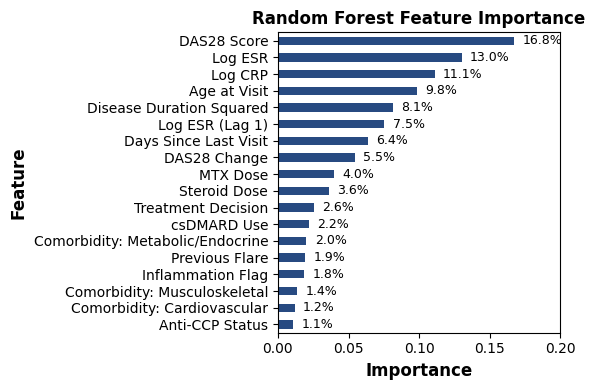

In [11]:
mask = df_cleaned['flare_next_visit'].notna()
X = df_cleaned.loc[mask, all_candidates].copy()
y = df_cleaned.loc[mask, 'flare_next_visit']
groups = df_cleaned.loc[mask, 'patient_id']

cat_cols = X.select_dtypes(include=['category', 'object', 'str']).columns
if not cat_cols.empty:
    X[cat_cols] = OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1
    ).fit_transform(X[cat_cols].astype(str))

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=500, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1))
])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_importances = [
    clone(pipe).fit(X.iloc[tr], y.iloc[tr]).named_steps['clf'].feature_importances_
    for tr, _ in cv.split(X, y, groups=groups)
]

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': np.mean(fold_importances, axis=0),
    'importance_std': np.std(fold_importances, axis=0),
    'cv_ratio':       np.std(fold_importances, axis=0) /
                      (np.mean(fold_importances, axis=0) + 1e-10)
}).sort_values('importance', ascending=False)

print("\nCROSS-VALIDATED RF FEATURE IMPORTANCE RANKING:")
print(importance_df.to_string(index=False))


stable_important = importance_df[
    (importance_df['importance'] > importance_df['importance'].median()) & 
    (importance_df['cv_ratio'] < 1.0)
]

print(f"\nStable and important features selected: {len(stable_important)}")
print(stable_important['feature'].tolist())

#Dictionary to display cleaner feature labels in the bar chart.
feature_label_map = {
    'das28_score': 'DAS28 Score',
    'das28_change': 'DAS28 Change',
    'log_esr': 'Log ESR',
    'log_crp_normalized': 'Log CRP',
    'log_esr_lag1': 'Log ESR (Lag 1)',
    'inflammation_flag': 'Inflammation Flag',
    'age_at_visit': 'Age at Visit',
    'previous_flare': 'Previous Flare',
    'disease_duration_squared': 'Disease Duration Squared',
    'days_since_last_visit': 'Days Since Last Visit',
    'anti_ccp_status': 'Anti-CCP Status',
    'mtx_dose': 'MTX Dose',
    'steroid_dose': 'Steroid Dose',
    'csdmard_use': 'csDMARD Use',
    'treatment_decision_grouped': 'Treatment Decision',
    'comorb_cardiovascular': 'Comorbidity: Cardiovascular',
    'comorb_musculoskeletal': 'Comorbidity: Musculoskeletal',
    'comorb_metabolic_endocrine': 'Comorbidity: Metabolic/Endocrine'
}

plot_df = importance_df.copy()
plot_df['feature_clean'] = plot_df['feature'].map(feature_label_map).fillna(plot_df['feature'])

fig, ax = plt.subplots(figsize=(6,4))
plot_df.plot(kind='barh', x='feature_clean', y='importance', ax=ax, color='#274a81', legend=False)
ax.bar_label(ax.containers[0], labels=[f'{v*100:.1f}%' for v in plot_df['importance']], padding=6, fontsize=9)
ax.set_xlim(0, plot_df['importance'].max() * 1.45)
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Feature Importance', fontweight='bold', fontsize=12)
ax.set_xlim(0, 0.2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

A Random Forest classifier evaluated non-linear feature interactions and cross-fold stability (mean importance and coefficient of variation ratio, $\text{CV ratio} = \sigma / \mu$):  

Top-Tier Predictors (Core Biological Signal):  
- das28_score dominated overall importance (mean = $0.168$, CV ratio = $0.064$)  
- log_esr ($0.130$) and log_crp ($0.111$).   
Together, these three features drove the majority of split-criterion gains.  
Temporal & Demographic Momentum:  
- age_at_visit ($0.098$) ranked 4th
- disease_duration_squared ($0.081$) ranked 5th.  
- log_esr_lag1 ($0.075$) and das28_change ($0.054$)—contributed non-redundant trajectory signal  
- days_since_last_visit ($0.064$) emerged as the most stable feature across folds (CV ratio = $0.025$).  
Selection Outcome: 9 continuous/temporal features met the automated stability threshold ($\text{importance} > \text{median}$, $\text{CV ratio} < 1.0$), paired with clinically protected binary flags and controls to form the finalized modeling subset.

### 4. Clinical Preservations Despite Low Impurity Gains

Medications & History:  
- mtx_dose ($0.040$)  
- steroid_dose ($0.036$)  
- treatment_decision ($0.026$)  
, were retained as clinical proxies for physician-assessed disease severity.  

Binary Penalty Correction:  
Binary flags (previous_flare, inflammation_flag, anti_ccp_status) scored low importance ($<0.020$) due to Gini impurity's well-known bias toward high-cardinality continuous scales; both flags were preserved given their strong univariate significance.  

Comorbidity Controls:  
Prevalent comorbidity categories (cardiovascular, musculoskeletal, metabolic) were retained as essential clinical baseline controls.